# Assesment Natalia Rojas Otero

## Entorno de desarrollo y reproducibilidad

El proyecto se desarrolló utilizando Python 3.12.13 dentro de un entorno virtual creado mediante Conda. El entorno permite aislar las dependencias utilizadas en el proyecto y evitar conflictos con otras instalaciones de Python.

Las librerias necesarias para ejecutar el proyecto se descargaron mediante pip y serán documentadas en requirements.txt, permitiendo reproducir el entorno en otra máquina.

A partir de esto para la exploración de datos se utiliza el presente notebook .ipynb ejecutado directamente desde Visual Studio Code mediante el kernel asociado al entorno prueba_dsm.

## Data profiling

### Extracción

In [1]:
from pathlib import Path #Otorga una ruta relativa para reproducibilidad
import pandas as pd
import json

In [2]:
BASE_DIR = Path("..") 
DATA_DIR = BASE_DIR / "data"

A partir de la ruta relativa procedo a nombrar cada uno de los archivos para entender como vienen los datos. 

Los archivos CSV, TXT y Excel presentan una estructura tabular que puede representarse directamente mediante un DataFrame. Por ello, uso pandas para realizar su lectura y almacenamiento inicial, conservando los registros y columnas originales para facilitar las etapas posteriores de exploración y calidad de datos.

In [80]:
clientes = pd.read_excel(DATA_DIR / "clientes.xlsx") 
productos = pd.read_excel(DATA_DIR / "productos.xlsx")
vendedores = pd.read_csv(DATA_DIR / "vendedores.txt", sep="|") #especificidad mencionada en instructivo
ventas = pd.read_csv(DATA_DIR / "ventas.csv")

Para cuotas al ser un archivo JSON primero confirmo la estructura en la que esta construido para entender si es informacion organizada que se puede trasladar a un dataframe.

In [4]:
with open(DATA_DIR / "cuotas.json", "r", encoding="utf-8") as file:
    cuotas_raw = json.load(file)
print("El tipo de JSON es: ",type(cuotas_raw))

El tipo de JSON es:  <class 'list'>


In [5]:
cuotas_raw[:5]

[{'id_vendedor': 'V001',
  'periodo': '2024-01',
  'cuota_mensual': 36349574.0,
  'region': 'Caribe'},
 {'id_vendedor': 'V001',
  'periodo': '2024-02',
  'cuota_mensual': 17790799.0,
  'region': 'Caribe'},
 {'id_vendedor': 'V001',
  'periodo': '2024-03',
  'cuota_mensual': 42638232.0,
  'region': 'Caribe'},
 {'id_vendedor': 'V001',
  'periodo': '2024-04',
  'cuota_mensual': 41918624.0,
  'region': 'Caribe'},
 {'id_vendedor': 'V001',
  'periodo': '2024-05',
  'cuota_mensual': 30592777.0,
  'region': 'Caribe'}]

In [81]:
cuotas = pd.DataFrame(cuotas_raw)

In [7]:
cuotas.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_vendedor    400 non-null    str    
 1   periodo        400 non-null    str    
 2   cuota_mensual  400 non-null    float64
 3   region         400 non-null    str    
dtypes: float64(1), str(3)
memory usage: 12.6 KB


### Limpieza y calidad

A partir del conocimiento incial de la información genero graficos que me permitan observar el peso de los valores nulos dentro de cada dataframe

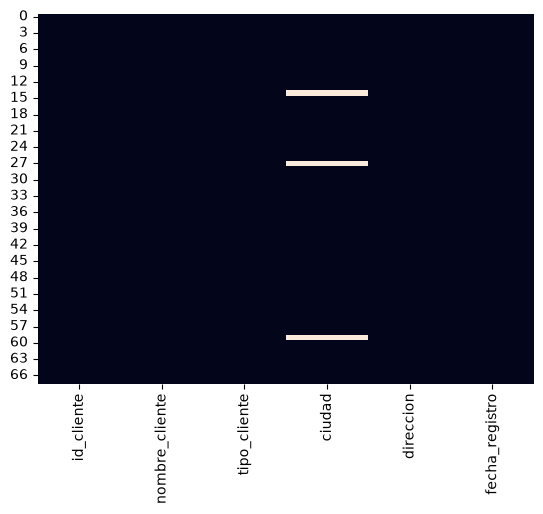

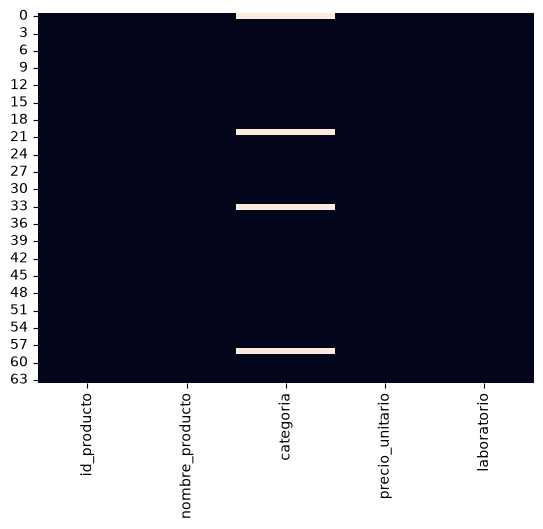

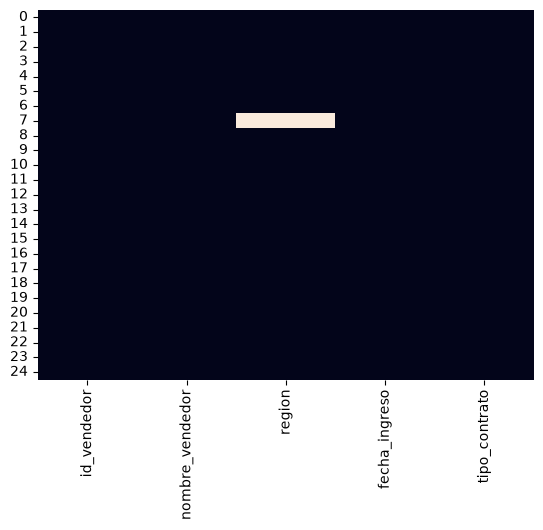

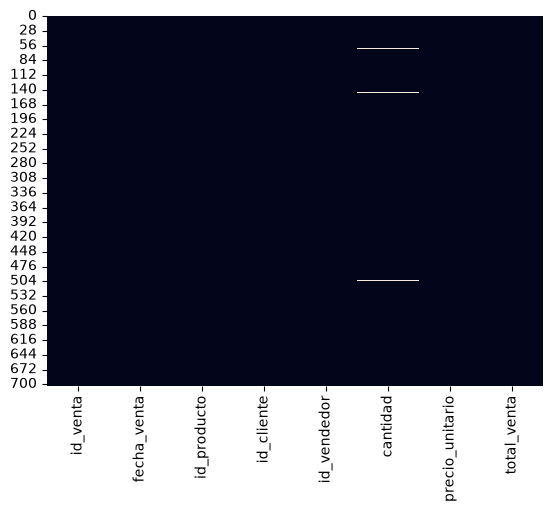

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

for df in [clientes, productos, vendedores, ventas]:
    plt.figure()
    sns.heatmap(df.isnull(), cbar=False)
    plt.show()

Como primera observación general en los 4 dataframes correspondientes a clientes, productos, vendedores y ventas existen valores nulos en porcentajes menores al 10% por lo que para cada una de las tablas se revisará en especifico el tratamiento y necesidad de esta información.

#### Estandarización de fechas

Al identificar las columnas relacionadas con tiempo se transforma el tipo con el fin de evitar errores al pasar a un entorno de visualización.

In [83]:
def convertir_fecha_robusta_v2(columna_fecha):
    def convertir_valor(valor):
        if pd.isna(valor) or valor == '':
            return pd.NaT
        
        valor_str = str(valor).strip()
        
        # Lista de formatos posibles
        formatos = [
            "%Y-%m-%d",    # 2021-05-24
            "%d/%m/%Y",    # 24/07/2021
            "%m/%d/%Y",    # 05/24/2021
            "%d-%m-%Y",    # 13-04-2020
            "%m-%d-%Y",    # 04-13-2020
            "%d.%m.%Y",    # 24.07.2021
            "%Y%m%d",      # 20210524
        ]
        
        for formato in formatos:
            try:
                return pd.to_datetime(valor_str, format=formato)
            except ValueError:
                continue
        
        # Si ningún formato funciona,  inferencia automática
        try:
            return pd.to_datetime(valor_str, infer_datetime_format=True)
        except:
            return pd.NaT
    
    # Aplicar a cada valor
    return pd.Series([convertir_valor(v) for v in columna_fecha])

# Aplicar a cada tabla
print("Convirtiendo fechas de CLIENTES...")
clientes["fecha_registro"] = convertir_fecha_robusta_v2(clientes["fecha_registro"])
print(f"Nulos después de conversión: {clientes['fecha_registro'].isna().sum()}")

print("\nConvirtiendo fechas de VENTAS...")
ventas["fecha_venta"] = convertir_fecha_robusta_v2(ventas["fecha_venta"])
print(f"Nulos después de conversión: {ventas['fecha_venta'].isna().sum()}")

print("\nConvirtiendo fechas de VENDEDORES...")
vendedores["fecha_ingreso"] = convertir_fecha_robusta_v2(vendedores["fecha_ingreso"])
print(f"Nulos después de conversión: {vendedores['fecha_ingreso'].isna().sum()}")


Convirtiendo fechas de CLIENTES...
Nulos después de conversión: 0

Convirtiendo fechas de VENTAS...
Nulos después de conversión: 0

Convirtiendo fechas de VENDEDORES...
Nulos después de conversión: 0


In [84]:
# Para periodo en especial es importante tener en cuenta que no es una fecha fija de dia porque corresponde a un mes
cuotas["periodo"] = pd.to_datetime(cuotas["periodo"], format="%Y-%m")  
print(f"Nulos después de conversión: {cuotas["periodo"].isna().sum()}")

Nulos después de conversión: 0


#### Revisión de registros duplicados por tabla

Inicialmente se realizara la revisión de duplicados en las tablas de dimensión ya que al realizar el relacionamiento se obtendra información errada en especial al tener en cuenta que los IDs deben corresponder a llaves unicas dentro de cada dataframe.

In [85]:
def revisar_duplicados(df):
    duplicados = df[df.duplicated(keep=False)]
    
    print(f"Registros duplicados encontrados: {duplicados.shape[0]}")
    
    if duplicados.empty:
        print("No se encontraron registros duplicados.")
    else:
        display(duplicados.sort_values(by=df.columns.tolist()))
    
    return duplicados

In [86]:
duplicados_clientes = revisar_duplicados(clientes)

Registros duplicados encontrados: 2


,id_cliente,nombre_cliente,tipo_cliente,ciudad,direccion,fecha_registro
5,C0006,Cruz Verde,Cadena,PEREIRA,Calle 117 # 37-55,2023-11-27
66,C0006,Cruz Verde,Cadena,PEREIRA,Calle 117 # 37-55,2023-11-27


In [87]:
duplicados_productos = revisar_duplicados(productos)


Registros duplicados encontrados: 4


,id_producto,nombre_producto,categoria,precio_unitario,laboratorio
5,P0006,Loratadina 10mg,Antialérgico,5122,Tecnoquímicas
60,P0006,Loratadina 10mg,Antialérgico,5122,Tecnoquímicas
15,P0016,Loperamida 2mg,Gastrointestinal,10932,Pfizer
61,P0016,Loperamida 2mg,Gastrointestinal,10932,Pfizer


In [88]:
duplicados_vendedores = revisar_duplicados(vendedores)
duplicados_cuotas = revisar_duplicados(cuotas)


Registros duplicados encontrados: 0
No se encontraron registros duplicados.
Registros duplicados encontrados: 0
No se encontraron registros duplicados.


In [89]:
duplicados_cuotas = revisar_duplicados(ventas)

Registros duplicados encontrados: 6


,id_venta,fecha_venta,id_producto,id_cliente,id_vendedor,cantidad,precio_unitario,total_venta
100,VT00101,2024-02-11,P0022,C0049,V011,14,70926.0,992964.0
700,VT00101,2024-02-11,P0022,C0049,V011,14,70926.0,992964.0
250,VT00251,2024-09-16,P0035,C0067,V002,13,24771.0,322023.0
701,VT00251,2024-09-16,P0035,C0067,V002,13,24771.0,322023.0
400,VT00401,2024-09-02,P0013,C0035,V018,4,60097.0,240388.0
702,VT00401,2024-09-02,P0013,C0035,V018,4,60097.0,240388.0


Al identificar que en clientes y productos hay valores duplicados que corresponden exactamente a la misma información se usara el codigo correspondiente para mantener la primera aparición y eliminar las siguientes.

In [90]:
registros_antes = len(clientes)

clientes = clientes.drop_duplicates()

registros_despues = len(clientes)
registros_eliminados = registros_antes - registros_despues

print(f"Registros antes: {registros_antes}")
print(f"Registros eliminados: {registros_eliminados}")
print(f"Registros después: {registros_despues}")

duplicados_clientes = revisar_duplicados(clientes)

Registros antes: 68
Registros eliminados: 1
Registros después: 67
Registros duplicados encontrados: 0
No se encontraron registros duplicados.


In [91]:
registros_antes = len(productos)

productos = productos.drop_duplicates()

registros_despues = len(productos)
registros_eliminados = registros_antes - registros_despues

print(f"Registros antes: {registros_antes}")
print(f"Registros eliminados: {registros_eliminados}")
print(f"Registros después: {registros_despues}")

duplicados_clientes = revisar_duplicados(productos)

Registros antes: 64
Registros eliminados: 2
Registros después: 62
Registros duplicados encontrados: 0
No se encontraron registros duplicados.


In [92]:
registros_antes = len(ventas)

ventas = ventas.drop_duplicates()

registros_despues = len(ventas)
registros_eliminados = registros_antes - registros_despues

print(f"Registros antes: {registros_antes}")
print(f"Registros eliminados: {registros_eliminados}")
print(f"Registros después: {registros_despues}")

duplicados_clientes = revisar_duplicados(ventas)

Registros antes: 703
Registros eliminados: 3
Registros después: 700
Registros duplicados encontrados: 0
No se encontraron registros duplicados.


#### Revision detallada 

Con el fin de iniciar la estandarización de datos y toma de desiciones para valores nulos se revisara cada una de las tablas a partir de una función y para cada columna se traeran los valores unicos y su conteo así sera mas facil encontrar los campos especificos a modificar.

In [93]:
# Función que replicare para cada dataframe
def resumen_calidad(df, nombre_tabla="Tabla"):
    
    print(f"\n{nombre_tabla.upper()}")
    print("=" * 70)
    print(f"Registros: {len(df)}")
    print(f"Columnas: {len(df.columns)}")

    
    resumen = pd.DataFrame({
        "tipo": df.dtypes,
        "nulos": df.isna().sum(),
        "% nulos": (df.isna().mean() * 100).round(2),
        "valores_unicos": df.nunique(dropna=True)
    })
    
    display(resumen)

In [94]:
resumen_calidad(clientes, "Clientes")
resumen_calidad(vendedores,"Vendedores")
resumen_calidad(productos,"Productos")
resumen_calidad(cuotas,"Cuotas")
resumen_calidad(ventas,"Ventas")


CLIENTES
Registros: 67
Columnas: 6


,tipo,nulos,% nulos,valores_unicos
id_cliente,str,0,0.00,67
nombre_cliente,str,0,0.00,22
tipo_cliente,str,0,0.00,2
ciudad,str,3,4.48,30
direccion,str,0,0.00,66
fecha_registro,datetime64[us],0,0.00,65



VENDEDORES
Registros: 25
Columnas: 5


,tipo,nulos,% nulos,valores_unicos
id_vendedor,str,0,0.0,25
nombre_vendedor,str,0,0.0,25
region,str,1,4.0,5
fecha_ingreso,datetime64[us],0,0.0,23
tipo_contrato,str,0,0.0,2



PRODUCTOS
Registros: 62
Columnas: 5


,tipo,nulos,% nulos,valores_unicos
id_producto,str,0,0.00,62
nombre_producto,str,0,0.00,62
categoria,str,4,6.45,15
precio_unitario,int64,0,0.00,62
laboratorio,str,0,0.00,9



CUOTAS
Registros: 400
Columnas: 4


,tipo,nulos,% nulos,valores_unicos
id_vendedor,str,0,0.0,25
periodo,datetime64[us],0,0.0,16
cuota_mensual,float64,0,0.0,400
region,str,0,0.0,5



VENTAS
Registros: 700
Columnas: 8


,tipo,nulos,% nulos,valores_unicos
id_venta,str,0,0.00,700
fecha_venta,datetime64[us],0,0.00,372
id_producto,str,0,0.00,60
id_cliente,str,0,0.00,67
id_vendedor,str,0,0.00,25
cantidad,str,5,0.71,17
precio_unitario,float64,0,0.00,60
total_venta,float64,0,0.00,486


A partir de la revisión general el criterio de revisión para los valores unicos de las columnas sera si la cantidad de valores unicos es menor o igual a la mitad del total de registros o si es relevante en el informe a desarrollar.

##### *Clientes*

Dentro de esta tabla se identifica como prioridad revisar las columnas correspondientes a ciudad y nombre_cliente.

Partiendo desde ciudad primero se hara una transformación relacionada a errores de ortografía eliminando tildes y dejando todas las ciudades en mayuscula de esta forma se espera reducir el numero de registros unicos.

In [95]:
import unicodedata

def normalizar_texto(valor):
    if pd.isna(valor):
        return valor
    
    valor = str(valor).upper().strip()
    valor = ''.join(
        c for c in unicodedata.normalize('NFD', valor)
        if unicodedata.category(c) != 'Mn'
    )
    
    return valor

In [96]:
clientes["ciudad"] = clientes["ciudad"].apply(normalizar_texto)

Luego de realizar la normalización se hace una revisión a detalle de errores de digitación y posterior una hom,ologacion de ciudades.

In [97]:
conteos_ciudad = clientes["ciudad"].value_counts().sort_index()
conteos_ciudad

ciudad
BARRANQUILA             3
BARRANQUILLA            9
BOGOTA                  1
BOGOTA D.C.             1
BOGTA                   1
BUCARAMANGA             5
CALI                    1
CARTAGENA               6
CARTAGENA DE INDIAS     4
CARTAJENA               3
CUCUTA                 10
IBAGUE                  3
MANISALES               1
MANIZALES               4
MEDELLIN                3
PEREIRA                 7
SANTIAGO DE CALI        2
Name: count, dtype: int64

In [98]:
homologacion_ciudades = {
    "BARRANQUILA": "BARRANQUILLA",
    "BOGOTA D.C.": "BOGOTA",
    "BOGTA": "BOGOTA",
    "CARTAGENA DE INDIAS": "CARTAGENA",
    "CARTAJENA": "CARTAGENA",
    "MANISALES": "MANIZALES",
    "SANTIAGO DE CALI": "CALI"
}

clientes["ciudad"] = clientes["ciudad"].replace(homologacion_ciudades)
conteos_ciudad = clientes["ciudad"].value_counts().sort_index()
conteos_ciudad

ciudad
BARRANQUILLA    12
BOGOTA           3
BUCARAMANGA      5
CALI             3
CARTAGENA       13
CUCUTA          10
IBAGUE           3
MANIZALES        5
MEDELLIN         3
PEREIRA          7
Name: count, dtype: int64

Incialmente aplicare la misma logica a nombre_cliente y revisare si es necesario crear homologaciones de nombre.

In [99]:
clientes["nombre_cliente"] = clientes["nombre_cliente"].apply(normalizar_texto)

In [100]:
conteos_ncliente = clientes["nombre_cliente"].value_counts().sort_index()
conteos_ncliente

nombre_cliente
CAFAM                        4
COLSUBSIDIO                  6
CRUZ VERDE                  12
DROGAS EL DORADO             1
DROGAS EL SOL                2
DROGAS EL VECINO             1
DROGAS LA 80                 1
DROGAS LA ESPERANZA          2
DROGAS LA REBAJA EXPRESS     3
DROGAS SAN JOSE              2
DROGUERIA LA ECONOMICA       1
FARMACIA CENTRAL             1
FARMACIA EL BOSQUE           2
FARMACIA LA FAMILIA          1
FARMACIA LOS ANDES           2
FARMACIA POPULAR             3
FARMACIA SAN RAFAEL          3
FARMACIA SANTA LUCIA         2
FARMATODO                    8
LA REBAJA                    4
OLIMPICA DROGAS              6
Name: count, dtype: int64

Debido a la estructuracion de los datos voy a realizar un filtrado adicional con el fin de tener identificados IDs de cliente con la misma informacion y realizar una busqueda en la tabla de hechos ventas para ver como se ve afectada por un fenomeno similar.

In [101]:
# Filtra y muestra los registros duplicados en 'nombre_cliente' y 'direccion'
duplicados = clientes[clientes.duplicated(subset=['nombre_cliente', 'direccion'], keep=False)]

# Muestra el resultado ordenado para comparar fácilmente los IDs diferentes
duplicados.sort_values(by=['nombre_cliente', 'direccion'])

,id_cliente,nombre_cliente,tipo_cliente,ciudad,direccion,fecha_registro
10,C0011,CRUZ VERDE,Cadena,BARRANQUILLA,Calle 31 # 73-32,2023-03-31
67,C0067,CRUZ VERDE,Cadena,BARRANQUILLA,Calle 31 # 73-32,2023-03-31


In [102]:
duplicados = clientes[clientes.duplicated(subset=['nombre_cliente', 'direccion'], keep=False)]
print(duplicados)  # revisa que solo salgan los 2 registros que ya identificaste

mapeo_ids = {}
for _, grupo in duplicados.groupby(['nombre_cliente', 'direccion']):
    id_nuevo = grupo.iloc[0]['id_cliente']              # primera aparición en el orden original
    ids_viejos = grupo.iloc[1:]['id_cliente'].tolist()  # el resto, a descartar
    for id_viejo in ids_viejos:
        mapeo_ids[id_viejo] = id_nuevo

print("Mapeo de IDs a reemplazar:", mapeo_ids)

# 3. Reasigna las ventas del ID viejo al ID nuevo
ventas['id_cliente'] = ventas['id_cliente'].replace(mapeo_ids)

# 4. Elimina el registro duplicado (el ID viejo) de la tabla de clientes
clientes = clientes[~clientes['id_cliente'].isin(mapeo_ids.keys())]

# 5. Verificación rápida: confirma que ya no queden esos IDs viejos en ventas
print("IDs viejos aún en ventas (debería ser 0):", ventas['id_cliente'].isin(mapeo_ids.keys()).sum())
print("Clientes totales después de la unificación:", len(clientes))

   id_cliente nombre_cliente tipo_cliente        ciudad         direccion  \
10      C0011     CRUZ VERDE       Cadena  BARRANQUILLA  Calle 31 # 73-32   
67      C0067     CRUZ VERDE       Cadena  BARRANQUILLA  Calle 31 # 73-32   

   fecha_registro  
10     2023-03-31  
67     2023-03-31  
Mapeo de IDs a reemplazar: {'C0067': 'C0011'}
IDs viejos aún en ventas (debería ser 0): 0
Clientes totales después de la unificación: 66


In [103]:
clientes[clientes.isnull().any(axis=1)]

,id_cliente,nombre_cliente,tipo_cliente,ciudad,direccion,fecha_registro
14,C0015,LA REBAJA,Cadena,NaN,Calle 3 # 59-80,2023-02-27
27,C0028,FARMATODO,Cadena,NaN,Calle 42 # 23-53,2020-02-20
59,C0060,FARMACIA LA FAMILIA,Independiente,NaN,Carrera 86 # 87-52,2024-01-23


Respecto a los valores nulos en ciudad no existe una fuente confiable para recuperar la información y el análisis solicitado se centra en región.

##### *Vendedores*

In [104]:
conteos_region = vendedores["region"].value_counts().sort_index()
conteos_region

region
Andina        5
Caribe       10
Orinoquía     4
PACIFICA      1
Pacífica      4
Name: count, dtype: int64

In [105]:
vendedores["region"] = vendedores["region"].apply(normalizar_texto)

In [106]:
conteos_region = vendedores["region"].value_counts().sort_index()
conteos_region


region
ANDINA        5
CARIBE       10
ORINOQUIA     4
PACIFICA      5
Name: count, dtype: int64

In [107]:
vendedores[vendedores.isnull().any(axis=1)]

,id_vendedor,nombre_vendedor,region,fecha_ingreso,tipo_contrato
7,V008,Catalina Torres,NaN,2023-06-14,Indefinido


Posterior a la estandarización y debido a que region contiene un unico valor nulo se extre este valor de la tabla de cuotas donde tembien  se encuentra la columna de región y por tanto podemos defirnir nuestro valor.

In [108]:
cuotas[cuotas["id_vendedor"] == "V008"]

,id_vendedor,periodo,cuota_mensual,region
112,V008,2024-01-01,42380310.0,Andina
113,V008,2024-02-01,30071798.0,Andina
114,V008,2024-03-01,26651438.0,Andina
115,V008,2024-04-01,20394476.0,Andina
116,V008,2024-05-01,24566327.0,Andina
117,V008,2024-06-01,21570606.0,Andina
118,V008,2024-07-01,41872943.0,Andina
119,V008,2024-08-01,38356148.0,Andina
120,V008,2024-09-01,16757737.0,Andina
121,V008,2024-10-01,44745940.0,Andina


In [109]:
region_vendedor = cuotas.groupby("id_vendedor")["region"].unique()

In [110]:
region_vendedor = region_vendedor[region_vendedor.apply(len) == 1].apply(lambda x: x[0])

In [111]:
vendedores["region"] = vendedores["region"].fillna(vendedores["id_vendedor"].map(region_vendedor))

##### *Productos*

In [112]:
conteos_categoria = productos["categoria"].value_counts().sort_index()
conteos_categoria

categoria
Analgésico           5
Antialérgico         3
Antibiótico          4
Colesterol           3
Cuidado Personal     5
Dermatológico        5
Diabetes             3
Dispositivos         5
Gastrointestinal     5
Hipertensión         3
Material Curación    1
Respiratorio         4
Sistema Nervioso     4
Soluciones           3
Vitaminas            5
Name: count, dtype: int64

In [113]:
conteos_categoria = productos["nombre_producto"].value_counts().sort_index()
conteos_categoria

nombre_producto
  Alcohol Antiséptico 250ml    1
  Alprazolam 0.5mg             1
  Insulina NPH                 1
ACETAMINOFEN 500MG             1
Acetaminofén 500mg             1
                              ..
cefalexina_500mg               1
hidrocortisona_crema           1
mascarilla_n95                 1
omeprazol_20mg                 1
vitamina_d3_2000ui             1
Name: count, Length: 62, dtype: int64

In [114]:
productos["nombre_producto"] = productos["nombre_producto"].apply(normalizar_texto)

In [115]:
conteos_categoria = productos["nombre_producto"].value_counts().sort_index()
print(conteos_categoria)

nombre_producto
ACETAMINOFEN 500MG           2
ACETILCISTEINA 600MG         1
ACIDO HIALURONICO SERUM      1
AGUA OXIGENADA 120ML         1
ALCOHOL ANTISEPTICO 250ML    1
                            ..
TERMOMETRO DIGITAL           1
TIRILLAS GLUCOSA X50         1
TOALLA HIGIENICA             1
VITAMINA C 1000MG            1
VITAMINA_D3_2000UI           1
Name: count, Length: 61, dtype: int64


In [116]:
productos[productos.isnull().any(axis=1)]

,id_producto,nombre_producto,categoria,precio_unitario,laboratorio
0,P0001,ACETAMINOFEN 500MG,NaN,55253,Genfar
20,P0021,ENALAPRIL 10MG,NaN,9001,La Santé
33,P0034,CALCIO + D,NaN,15981,Pfizer
58,P0059,GASAS ESTERILES X10,NaN,64447,Bayer


In [117]:
import re
from difflib import get_close_matches

def nombre_base(nombre):
    nombre = str(nombre).lower()
    nombre = re.sub(r'\b\d+(?:[.,]\d+)?\s*(?:mg|g|ml|mcg|ug|kg|%)\b', '', nombre)
    nombre = re.sub(r'\bx\s*\d+\b', '', nombre)
    return re.sub(r'\s+', ' ', nombre).strip()

In [118]:
productos["nombre_base"] = productos["nombre_producto"].apply(nombre_base)

In [119]:
reglas = {
    "acetaminofen": "Analgésico",
    "enalapril": "Hipertensión",
    "gasas": "Material Curación",
    "calcio": "Vitaminas"
}

for palabra, categoria in reglas.items():
    productos.loc[
        productos["nombre_base"].str.contains(palabra, case=False, na=False),
        "categoria"
    ] = categoria

##### *Cuotas*

In [120]:
conteos_cregion = cuotas["region"].value_counts().sort_index()
conteos_cregion

region
Andina        96
Caribe       160
Orinoquía     64
PACIFICA      16
Pacífica      64
Name: count, dtype: int64

In [121]:
cuotas["region"] = cuotas["region"].apply(normalizar_texto)

In [122]:
conteos_cregion = cuotas["region"].value_counts().sort_index()
conteos_cregion

region
ANDINA        96
CARIBE       160
ORINOQUIA     64
PACIFICA      80
Name: count, dtype: int64

In [123]:
conteos_c = cuotas["periodo"].value_counts().sort_index()
conteos_c

periodo
2024-01-01    25
2024-02-01    25
2024-03-01    25
2024-04-01    25
2024-05-01    25
2024-06-01    25
2024-07-01    25
2024-08-01    25
2024-09-01    25
2024-10-01    25
2024-11-01    25
2024-12-01    25
2025-01-01    25
2025-02-01    25
2025-03-01    25
2025-04-01    25
Name: count, dtype: int64

Con la revisión de la columna periodo me aseguro que cada vendedor tenga una cuota asignada para cada uno de los periodos de tiempo.

##### *Ventas*

Para ventas el foco sera en la columna con valores nulos la cual es cantidad, inicialmente se realizara a revisión detallada de porque corresponde a un string y a partir de la modificación se obtendrán los valores nulos a partir de la division del total venta entre el precio unitario del producto relacionado. 

In [124]:
conteos = ventas["cantidad"].value_counts().sort_index()
conteos

cantidad
1       48
10      51
11      57
12      55
13      47
14      38
15      41
2       34
3       39
4       50
5       46
6       50
7       50
8       42
9       45
diez     1
tres     1
Name: count, dtype: int64

In [125]:
ventas["cantidad"] = ventas["cantidad"].replace({"diez": 10, "tres": 3}) # cambiar caracteres a numero
ventas["cantidad"] = pd.to_numeric(ventas["cantidad"], errors="coerce").astype("Int64") # cambiar a tipo int

In [126]:
# Validacion de valores nulos
ventas[ventas["cantidad"].isna()][
    ["id_venta", "cantidad", "precio_unitario", "total_venta"]
]

,id_venta,cantidad,precio_unitario,total_venta
61,VT00062,<NA>,52307.0,732298.0
145,VT00146,<NA>,52753.0,738542.0
243,VT00244,<NA>,5122.0,61464.0
429,VT00430,<NA>,46567.0,512237.0
503,VT00504,<NA>,46567.0,46567.0


In [127]:
filas_nulas = ventas["cantidad"].isna()

ventas.loc[filas_nulas, "cantidad"] = (
    ventas.loc[filas_nulas, "total_venta"] /
    ventas.loc[filas_nulas, "precio_unitario"]
)

ventas.loc[filas_nulas, ["id_venta", "cantidad", "total_venta", "precio_unitario"]]

,id_venta,cantidad,total_venta,precio_unitario
61,VT00062,14,732298.0,52307.0
145,VT00146,14,738542.0,52753.0
243,VT00244,12,61464.0,5122.0
429,VT00430,11,512237.0,46567.0
503,VT00504,1,46567.0,46567.0


#### Validación final

La validación se realiza con el fin de identificar si hay registros de venta a id de cliente producto o vendedor no existentes, asi como cuotas asignadas a vendedores no existentes.

In [128]:
ventas[~ventas["id_cliente"].isin(clientes["id_cliente"])]

,id_venta,fecha_venta,id_producto,id_cliente,id_vendedor,cantidad,precio_unitario,total_venta


In [129]:
ventas[~ventas["id_producto"].isin(productos["id_producto"])]

,id_venta,fecha_venta,id_producto,id_cliente,id_vendedor,cantidad,precio_unitario,total_venta


In [130]:
ventas[~ventas["id_vendedor"].isin(vendedores["id_vendedor"])]

,id_venta,fecha_venta,id_producto,id_cliente,id_vendedor,cantidad,precio_unitario,total_venta


In [131]:
cuotas[~cuotas["id_vendedor"].isin(vendedores["id_vendedor"])]

,id_vendedor,periodo,cuota_mensual,region


La segunda validación se realiza respecto a la tabla dimensional de cuotas ya que se evidencia que en el Modelo Entidad Relación contiene dos atributos que no existen en la data original, por tanto se valida:

1- La necesidad de una llave unica de cuota validando si existe una unica cuota asignada por vendedor y periodo

2- La validacion de una unica región asignada a cada vendedor

In [132]:
cuotas.duplicated(
    subset=["id_vendedor", "periodo"]
).sum()

np.int64(0)

In [133]:
cuotas.groupby("id_vendedor")["region"].nunique().value_counts()

region
1    25
Name: count, dtype: int64

## MER

El modelo entidad-relación proporcionado presenta una inconsistencia en la entidad CUOTAS, ya que establece una relación mediante id_producto con la entidad PRODUCTOS.

Al contrastar el modelo con la estructura real de los datos, se hace evidente que la tabla de cuotas no contiene id_producto. Sus atributos son únicamente id_vendedor, periodo, cuota_mensual y region. Adicionalmente, la lógica de negocio establece que la cuota corresponde a una meta mensual asignada a cada vendedor, por lo que su relación natural es con VENDEDORES y no con PRODUCTOS.

La relación correcta es, por tanto, VENDEDORES 1:N CUOTAS, utilizando id_vendedor como llave foránea. Debido a que existe una cuota por vendedor y periodo, la combinación (id_vendedor, periodo) identifica de manera única cada registro de cuota, validación que se confirmó sobre los datos al no encontrarse duplicados.

Las cuotas tampoco corresponden directamente a una venta individual. Para evaluar el cumplimiento, las ventas deben agregarse por vendedor y periodo y posteriormente compararse con la cuota correspondiente al mismo vendedor y periodo. Por esta razón, la relación entre ventas y cuotas se entiende como una relación analítica basada en vendedor + periodo, y no como una relación directa de una cuota con una venta específica.

![MER farmaceutico.png](<attachment:MER farmaceutico.png>)
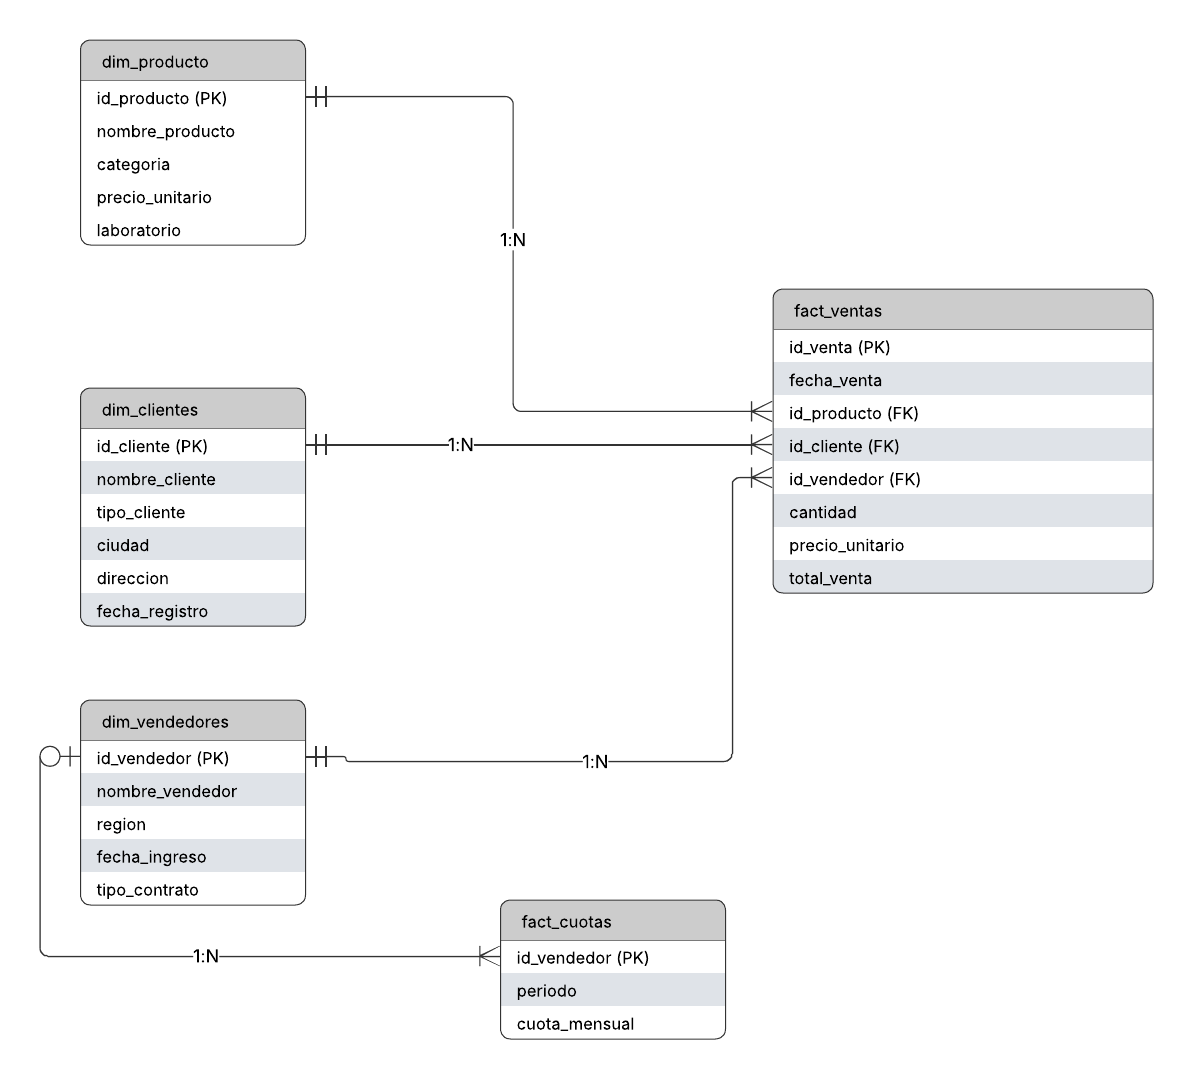

### Carga

In [60]:
# Creación de copias de trabajo para la base de datos
dim_clientes = clientes.copy()
dim_productos = productos.copy()
dim_vendedores = vendedores.copy()
fact_ventas = ventas.copy()
fact_cuotas = cuotas.copy()

In [61]:
dim_productos = dim_productos.drop(columns=["nombre_base"])

In [62]:
# Realizo la modificacion de region ya que previamente confirme que los vendedores riene una unica region
fact_cuotas = fact_cuotas.drop(columns=["region"])

In [63]:
# Creacion de la carpeta donde voy a guardar la BD SQL
from pathlib import Path

database_path = Path("../database")
database_path.mkdir(parents=True, exist_ok=True)

In [64]:
db_path = database_path / "ventas.db"

print(db_path)

..\database\ventas.db


In [65]:
import sqlite3

In [66]:
conn = sqlite3.connect(db_path)

#### Definición tablas y activación de las llaves foraneas

In [67]:
conn.execute("PRAGMA foreign_keys = ON;")

In [68]:
# Creacion para clientes
conn.execute("""
CREATE TABLE IF NOT EXISTS dim_clientes (
    id_cliente TEXT PRIMARY KEY,
    nombre_cliente TEXT,
    tipo_cliente TEXT,
    ciudad TEXT,
    direccion TEXT,
    fecha_registro DATE
);
""")

In [69]:
# Productos
conn.execute("""
CREATE TABLE IF NOT EXISTS dim_productos (
    id_producto TEXT PRIMARY KEY,
    nombre_producto TEXT,
    categoria TEXT,
    precio_unitario REAL,
    laboratorio TEXT
);
""")

In [70]:
# Vendedores
conn.execute("""
CREATE TABLE IF NOT EXISTS dim_vendedores (
    id_vendedor TEXT PRIMARY KEY,
    nombre_vendedor TEXT,
    region TEXT,
    fecha_ingreso DATE,
    tipo_contrato TEXT
);
""")

In [71]:
# Cuotas
conn.execute("""
CREATE TABLE IF NOT EXISTS fact_cuotas (
    id_vendedor TEXT,
    periodo TEXT,
    cuota_mensual REAL,
    PRIMARY KEY (id_vendedor, periodo),
    FOREIGN KEY (id_vendedor)
        REFERENCES dim_vendedores(id_vendedor)
);
""")

In [72]:
conn.execute("""
CREATE TABLE IF NOT EXISTS fact_ventas (
    id_venta TEXT PRIMARY KEY,
    fecha_venta DATE,
    id_producto TEXT,
    id_cliente TEXT,
    id_vendedor TEXT,
    cantidad INTEGER,
    precio_unitario REAL,
    total_venta REAL,
    FOREIGN KEY (id_producto)
        REFERENCES dim_productos(id_producto),
    FOREIGN KEY (id_cliente)
        REFERENCES dim_clientes(id_cliente),
    FOREIGN KEY (id_vendedor)
        REFERENCES dim_vendedores(id_vendedor)
);
""")

In [73]:
conn.commit()

In [74]:
# Validacion correcta creacion de tablas 
pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

,name
0,dim_clientes
1,dim_productos
2,dim_vendedores
3,fact_cuotas
4,fact_ventas


In [75]:
tablas = {
    "dim_clientes": dim_clientes,
    "dim_productos": dim_productos,
    "dim_vendedores": dim_vendedores,
    "fact_cuotas": fact_cuotas,
    "fact_ventas": fact_ventas
}

for tabla, df in tablas.items():
    columnas_sql = pd.read_sql_query(
        f"PRAGMA table_info({tabla});",
        conn
    )["name"].tolist()

    print(f"\n{tabla}")
    print("En DataFrame:", df.columns.tolist())
    print("En SQLite:   ", columnas_sql)


dim_clientes
En DataFrame: ['id_cliente', 'nombre_cliente', 'tipo_cliente', 'ciudad', 'direccion', 'fecha_registro']
En SQLite:    ['id_cliente', 'nombre_cliente', 'tipo_cliente', 'ciudad', 'direccion', 'fecha_registro']

dim_productos
En DataFrame: ['id_producto', 'nombre_producto', 'categoria', 'precio_unitario', 'laboratorio']
En SQLite:    ['id_producto', 'nombre_producto', 'categoria', 'precio_unitario', 'laboratorio']

dim_vendedores
En DataFrame: ['id_vendedor', 'nombre_vendedor', 'region', 'fecha_ingreso', 'tipo_contrato']
En SQLite:    ['id_vendedor', 'nombre_vendedor', 'region', 'fecha_ingreso', 'tipo_contrato']

fact_cuotas
En DataFrame: ['id_vendedor', 'periodo', 'cuota_mensual']
En SQLite:    ['id_vendedor', 'periodo', 'cuota_mensual']

fact_ventas
En DataFrame: ['id_venta', 'fecha_venta', 'id_producto', 'id_cliente', 'id_vendedor', 'cantidad', 'precio_unitario', 'total_venta']
En SQLite:    ['id_venta', 'fecha_venta', 'id_producto', 'id_cliente', 'id_vendedor', 'cantidad

#### Cargue con .tosql

In [76]:
dim_clientes.to_sql(
    "dim_clientes",
    conn,
    if_exists="append",
    index=False
)

DatabaseError: Execution failed

In [ ]:
dim_productos.to_sql(
    "dim_productos",
    conn,
    if_exists="append",
    index=False
)

62

In [ ]:
dim_vendedores.to_sql(
    "dim_vendedores",
    conn,
    if_exists="append",
    index=False
)

25

In [ ]:
fact_cuotas.to_sql(
    "fact_cuotas",
    conn,
    if_exists="append",
    index=False
)

400

In [ ]:
fact_ventas.to_sql(
    "fact_ventas",
    conn,
    if_exists="append",
    index=False
)

700

In [ ]:
# Validacion de cargue 
tablas = {
    "dim_clientes": dim_clientes,
    "dim_productos": dim_productos,
    "dim_vendedores": dim_vendedores,
    "fact_cuotas": fact_cuotas,
    "fact_ventas": fact_ventas
}

for tabla, df in tablas.items():
    cantidad_sql = pd.read_sql_query(
        f"SELECT COUNT(*) AS cantidad FROM {tabla}",
        conn
    ).iloc[0, 0]
    
    print(f"{tabla}: DataFrame = {len(df)} | SQLite = {cantidad_sql}")

dim_clientes: DataFrame = 66 | SQLite = 66
dim_productos: DataFrame = 62 | SQLite = 62
dim_vendedores: DataFrame = 25 | SQLite = 25
fact_cuotas: DataFrame = 400 | SQLite = 400
fact_ventas: DataFrame = 700 | SQLite = 700


In [ ]:
pd.read_sql_query(
    "PRAGMA foreign_key_check;",
    conn
)

,table,rowid,parent,fkid


In [ ]:
# Revision llave primaria creada 
pd.read_sql_query("""
SELECT id_vendedor, periodo, COUNT(*) AS cantidad
FROM fact_cuotas
GROUP BY id_vendedor, periodo
HAVING COUNT(*) > 1;
""", conn)

,id_vendedor,periodo,cantidad


### Consultas de SQL

Esta seccion se desarrolla con el fin de validar la correcta conexion y consulta a la BD creada

In [ ]:
pd.read_sql_query("""
SELECT *
FROM fact_ventas
LIMIT 5;
""", conn)

,id_venta,fecha_venta,id_producto,id_cliente,id_vendedor,cantidad,precio_unitario,total_venta
0,VT00001,2024-12-24 00:00:00,P0050,C0048,V006,5,64852.0,324260.0
1,VT00002,2024-11-06 00:00:00,P0048,C0015,V025,10,32365.0,323650.0
2,VT00003,2025-02-23 00:00:00,P0020,C0014,V019,3,12798.0,38394.0
3,VT00004,2024-01-14 00:00:00,P0020,C0049,V013,15,12798.0,191970.0
4,VT00005,2025-04-27 00:00:00,P0013,C0010,V019,12,60097.0,721164.0


In [ ]:
conn.close()

### Validación de consistencia entre ventas y cuotas.

Durante el desarrollo del Power BI se identifico una diferencia entre ventas y cuotas por lo que se comparó el total de ventas mensuales con la suma de las cuotas mensuales para el mismo periodo (enero 2024 – abril 2025). Los resultados muestran un cumplimiento promedio cercano al 2% durante todos los meses analizados, lo que indica que la diferencia entre ventas y cuotas es consistente a lo largo del tiempo y no corresponde a un error de integración o duplicación de datos. En consecuencia, las cuotas se interpretan como metas comerciales significativamente superiores al volumen de ventas registrado en el dataset.

📊 Ventas enero 2025: 47 registros
📊 Cuotas enero 2025: 25 registros
💰 Total ventas: $19,135,226.00
💰 Total cuotas: $747,510,471.00


C:\Users\USER\AppData\Local\Temp\ipykernel_6188\4150107027.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos_boxplot, x='tipo', y='valor', palette=['#2E86AB', '#A23B72'])


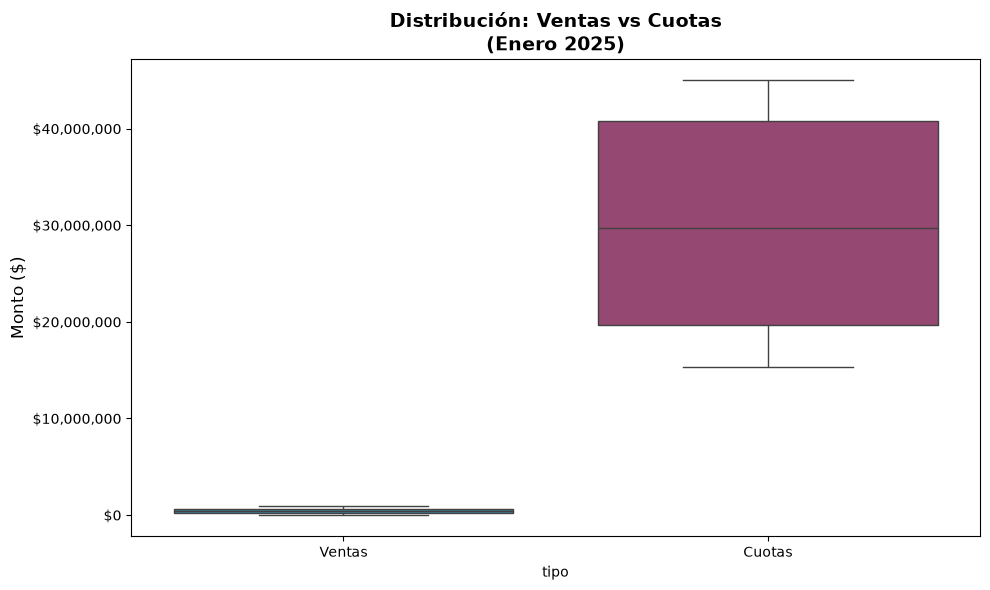

In [134]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

ventas_enero = ventas.loc[
    (ventas['fecha_venta'].dt.year == 2025) & 
    (ventas['fecha_venta'].dt.month == 1)
].copy()

# Filtrar cuotas de enero 2025
cuotas_enero = cuotas.loc[
    (cuotas['periodo'].dt.year == 2025) & 
    (cuotas['periodo'].dt.month == 1)
].copy()

print(f"📊 Ventas enero 2025: {len(ventas_enero)} registros")
print(f"📊 Cuotas enero 2025: {len(cuotas_enero)} registros")
print(f"💰 Total ventas: ${ventas_enero['total_venta'].sum():,.2f}")
print(f"💰 Total cuotas: ${cuotas_enero['cuota_mensual'].sum():,.2f}")
# Preparar datos
datos_boxplot = pd.DataFrame({
    'valor': pd.concat([
        ventas_enero['total_venta'],
        cuotas_enero['cuota_mensual']
    ]),
    'tipo': ['Ventas'] * len(ventas_enero) + ['Cuotas'] * len(cuotas_enero)
}).dropna()

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=datos_boxplot, x='tipo', y='valor', palette=['#2E86AB', '#A23B72'])
ax.set_title('Distribución: Ventas vs Cuotas\n(Enero 2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Monto ($)', fontsize=12)

# ✅ Formatear eje Y con dólares
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

In [135]:
# Relacionar ventas con vendedores (región) y clientes (ciudad)
ciudades_por_region = (
    ventas
    .merge(
        vendedores[["id_vendedor", "region"]],
        on="id_vendedor",
        how="left"
    )
    .merge(
        clientes[["id_cliente", "ciudad"]],
        on="id_cliente",
        how="left"
    )
)

# Obtener las ciudades únicas por región
ciudades_por_region = (
    ciudades_por_region
    .groupby("region")["ciudad"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .reset_index()
)

ciudades_por_region

,region,ciudad
0,ANDINA,"[BARRANQUILLA, BOGOTA, BUCARAMANGA, CALI, CART..."
1,Andina,"[BARRANQUILLA, BOGOTA, CALI, CARTAGENA, CUCUTA..."
2,CARIBE,"[BARRANQUILLA, BOGOTA, BUCARAMANGA, CALI, CART..."
3,ORINOQUIA,"[BARRANQUILLA, BOGOTA, BUCARAMANGA, CALI, CART..."
4,PACIFICA,"[BARRANQUILLA, BOGOTA, BUCARAMANGA, CALI, CART..."
